<a href="https://colab.research.google.com/github/kamalahmadov474/Machine_Learning/blob/main/Bank_ML_Project_Logistic_Regression%2C_XGBoost%2C_LightGBM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Libraries

In [17]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import matplotlib.pyplot as plt

2. Load Dataset

In [18]:
url = "https://raw.githubusercontent.com/selva86/datasets/master/bank-full.csv"
df = pd.read_csv(url, sep=';')

print("Data Shape:", df.shape)
df.head()

Data Shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


Plot Target Distribution

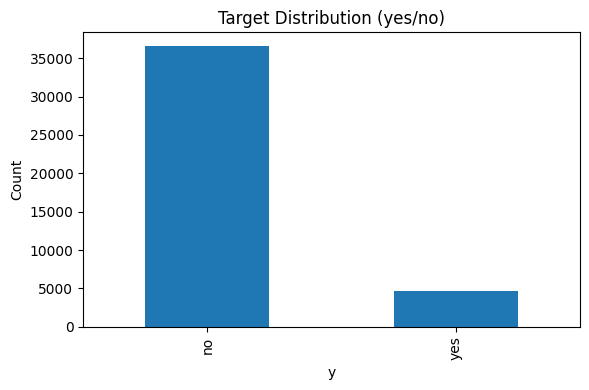

In [19]:
plt.figure(figsize=(6,4))
df["y"].value_counts().plot(kind="bar")
plt.title("Target Distribution (yes/no)")
plt.xlabel("y")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

3. Preprocessing

Convert categorical variables to dummy/one-hot

In [20]:
df = pd.get_dummies(df, drop_first=True)

# Target variable
y = df['y_yes']
X = df.drop('y_yes', axis=1)

# Train–test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale numeric features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

4. Logistic Regression

In [28]:
log_model = LogisticRegression(max_iter=200)
log_model.fit(X_train_scaled, y_train)
log_pred = log_model.predict(X_test_scaled)
log_acc = accuracy_score(y_test, log_pred)
log_f1 = f1_score(y_test, log_pred)


print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, log_pred))
print("F1 Score:", f1_score(y_test, log_pred))
print(classification_report(y_test, log_pred))

=== Logistic Regression ===
Accuracy: 0.9115076474872542
F1 Score: 0.526930564568462
              precision    recall  f1-score   support

       False       0.93      0.97      0.95      7303
        True       0.67      0.43      0.53       935

    accuracy                           0.91      8238
   macro avg       0.80      0.70      0.74      8238
weighted avg       0.90      0.91      0.90      8238



5. XGBoost

In [26]:
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    eval_metric='logloss'
)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
xgb_acc = accuracy_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)


print("\n=== XGBoost ===")
print("Accuracy:", accuracy_score(y_test, xgb_pred))
print("F1 Score:", f1_score(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred))


=== XGBoost ===
Accuracy: 0.917941247875698
F1 Score: 0.6009445100354192
              precision    recall  f1-score   support

       False       0.94      0.97      0.95      7303
        True       0.67      0.54      0.60       935

    accuracy                           0.92      8238
   macro avg       0.81      0.76      0.78      8238
weighted avg       0.91      0.92      0.91      8238



6. LightGBM

In [27]:
lgb = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1
)
lgb.fit(X_train, y_train)
lgb_pred = lgb.predict(X_test)
lgb_acc = accuracy_score(y_test, lgb_pred)
lgb_f1 = f1_score(y_test, lgb_pred)

print("\n=== LightGBM ===")
print("Accuracy:", accuracy_score(y_test, lgb_pred))
print("F1 Score:", f1_score(y_test, lgb_pred))
print(classification_report(y_test, lgb_pred))

[LightGBM] [Info] Number of positive: 3705, number of negative: 29245
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007291 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 761
[LightGBM] [Info] Number of data points in the train set: 32950, number of used features: 51
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.112443 -> initscore=-2.066025
[LightGBM] [Info] Start training from score -2.066025

=== LightGBM ===
Accuracy: 0.9172129157562515
F1 Score: 0.6066897347174164
              precision    recall  f1-score   support

       False       0.95      0.96      0.95      7303
        True       0.66      0.56      0.61       935

    accuracy                           0.92      8238
   macro avg       0.80      0.76      0.78      8238
weighted avg       0.91      0.92      0.91      8238



7. Compare Models – Bar Chart

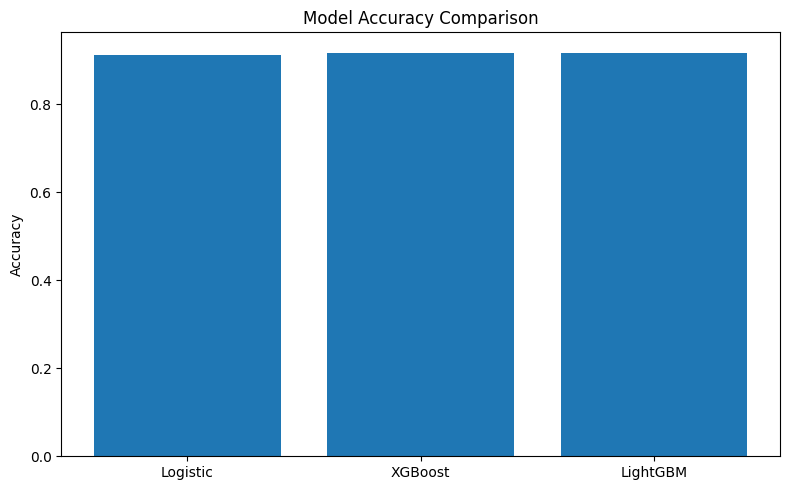

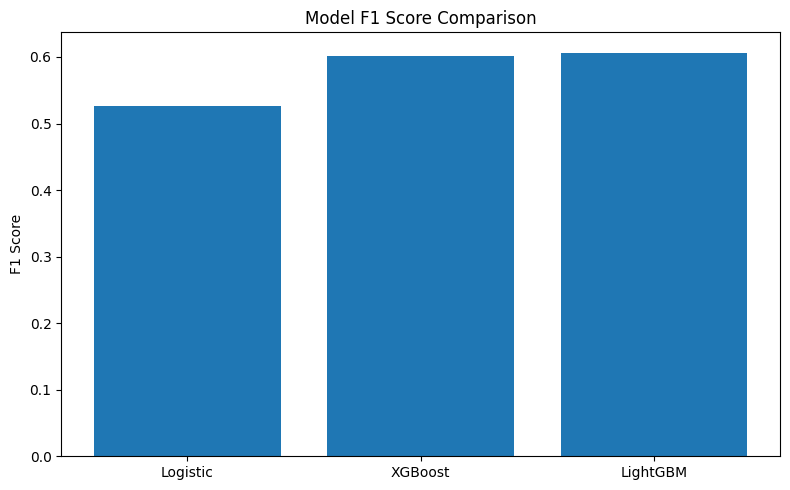

In [29]:
models = ["Logistic", "XGBoost", "LightGBM"]
accuracy_scores = [log_acc, xgb_acc, lgb_acc]
f1_scores = [log_f1, xgb_f1, lgb_f1]

plt.figure(figsize=(8,5))
plt.bar(models, accuracy_scores)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
plt.bar(models, f1_scores)
plt.title("Model F1 Score Comparison")
plt.ylabel("F1 Score")
plt.tight_layout()
plt.show()

8. XGBoost Top 10 Features Graph

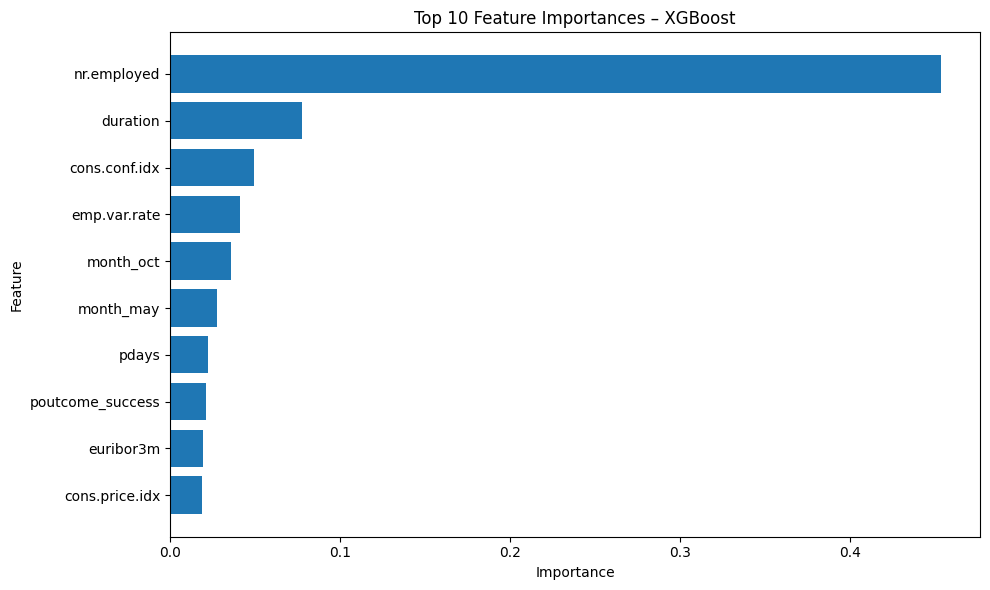

In [31]:
importance = xgb.feature_importances_
feat_names = X.columns

# Top 10
top_idx = np.argsort(importance)[-10:]
top_features = feat_names[top_idx]
top_importances = importance[top_idx]

plt.figure(figsize=(10,6))
plt.barh(top_features, top_importances)
plt.title("Top 10 Feature Importances – XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()